In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_excel('Admission.xlsx')

In [3]:
df.head(3)

,SlNo,Gender,Percent_SSC,Board_SSC,Percent_HSC,Board_HSC,Stream_HSC,Percent_Degree,Course_Degree,Experience_Yrs,Entrance_Test,Percentile_ET,Percent_MBA,Specialization_MBA,Marks_Communication,Marks_Projectwork,Marks_BOCA,Placement,Salary
0,1,M,62.00,Others,88.00,Others,Commerce,52.00,Science,0,MAT,55.0,58.80,Marketing & HR,50,65,74,Placed,270000
1,2,M,76.33,ICSE,75.33,Others,Science,75.48,Computer Applications,1,MAT,86.5,66.28,Marketing & Finance,69,70,75,Placed,200000
2,3,M,72.00,Others,78.00,Others,Commerce,66.63,Engineering,0,NaN,0.0,52.91,Marketing & Finance,50,61,59,Placed,240000


In [4]:
# details of an MBA student. 
# we need to predict the salaryu of MBA student if he gets placed. 

In [5]:
df_reg = df.drop(columns='Placement') # Salary as Target Variable (Regression Problem Solve) 

In [6]:
df_class = df.drop(columns='Salary')  # Placement as Target Variable (Classification Problem)

In [7]:
# Lets Work on the Regression Problem. 

In [8]:
# Problem Statement. 
# xyz is the client and they want help of a Machine Learning Algorithm in predicting salaries of a newly 
# graduated MBA students. Provided the data as a data analyst create a Regression ALgorithm according to 
# client use case. 

In [9]:
df_reg.head()

,SlNo,Gender,Percent_SSC,Board_SSC,Percent_HSC,Board_HSC,Stream_HSC,Percent_Degree,Course_Degree,Experience_Yrs,Entrance_Test,Percentile_ET,Percent_MBA,Specialization_MBA,Marks_Communication,Marks_Projectwork,Marks_BOCA,Salary
0,1,M,62.00,Others,88.00,Others,Commerce,52.00,Science,0,MAT,55.0,58.80,Marketing & HR,50,65,74,270000
1,2,M,76.33,ICSE,75.33,Others,Science,75.48,Computer Applications,1,MAT,86.5,66.28,Marketing & Finance,69,70,75,200000
2,3,M,72.00,Others,78.00,Others,Commerce,66.63,Engineering,0,NaN,0.0,52.91,Marketing & Finance,50,61,59,240000
3,4,M,60.00,CBSE,63.00,CBSE,Arts,58.00,Management,0,MAT,75.0,57.80,Marketing & Finance,54,66,62,250000
4,5,M,61.00,CBSE,55.00,ISC,Science,54.00,Engineering,1,MAT,66.0,59.43,Marketing & HR,52,65,67,180000


In [10]:
# Lets Understand the Problem Statement.
# Lets Understand the Dataset.

In [11]:
# Data Cleaning: 

# Have a look at the data. 
# Understand the number of variables and records

In [12]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 391 non-null    int64  
 1   Gender               391 non-null    object 
 2   Percent_SSC          391 non-null    float64
 3   Board_SSC            391 non-null    object 
 4   Percent_HSC          391 non-null    float64
 5   Board_HSC            391 non-null    object 
 6   Stream_HSC           391 non-null    object 
 7   Percent_Degree       391 non-null    float64
 8   Course_Degree        391 non-null    object 
 9   Experience_Yrs       391 non-null    int64  
 10  Entrance_Test        324 non-null    object 
 11  Percentile_ET        391 non-null    float64
 12  Percent_MBA          391 non-null    float64
 13  Specialization_MBA   391 non-null    object 
 14  Marks_Communication  391 non-null    int64  
 15  Marks_Projectwork    391 non-null    int

In [13]:
df_reg.isnull().sum()   # we can clearly see Entrance test has Missing Values

SlNo                    0
Gender                  0
Percent_SSC             0
Board_SSC               0
Percent_HSC             0
Board_HSC               0
Stream_HSC              0
Percent_Degree          0
Course_Degree           0
Experience_Yrs          0
Entrance_Test          67
Percentile_ET           0
Percent_MBA             0
Specialization_MBA      0
Marks_Communication     0
Marks_Projectwork       0
Marks_BOCA              0
Salary                  0
dtype: int64

In [14]:
# Lets handle them
df_reg['Entrance_Test'].value_counts(normalize=True)

# Missing value imputation technique for Categorical - Mode Imputation/Proportion Imputation/Logical.

Entrance_Test
MAT      0.817901
K-MAT    0.074074
CAT      0.067901
PGCET    0.024691
GCET     0.006173
G-MAT    0.003086
XAT      0.003086
G-SAT    0.003086
Name: proportion, dtype: float64

In [15]:
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [16]:
# since MAT is outright domination the sub groups proportion we will fill the missing values with Mode(MAT)
df_reg['Entrance_Test'].fillna('MAT',inplace=True)

In [17]:
df_reg.isnull().sum()

SlNo                   0
Gender                 0
Percent_SSC            0
Board_SSC              0
Percent_HSC            0
Board_HSC              0
Stream_HSC             0
Percent_Degree         0
Course_Degree          0
Experience_Yrs         0
Entrance_Test          0
Percentile_ET          0
Percent_MBA            0
Specialization_MBA     0
Marks_Communication    0
Marks_Projectwork      0
Marks_BOCA             0
Salary                 0
dtype: int64

In [18]:
# Deal with Categorical Data. 

In [19]:
# Encoding Technique. 

In [20]:
# get_dummies

df_cat = df_reg.select_dtypes(exclude=np.number)

In [21]:
encoded_cat = pd.get_dummies(df_cat,drop_first=True,dtype='int')

In [22]:
df_num = df_reg.select_dtypes(include=np.number)

In [23]:
final_df = pd.concat([df_num,encoded_cat],axis=1)
final_df.head()
# lets remove the Serial No column as it wont add any values for our predictive analysis


,SlNo,Percent_SSC,Percent_HSC,Percent_Degree,Experience_Yrs,Percentile_ET,Percent_MBA,Marks_Communication,Marks_Projectwork,Marks_BOCA,...,Course_Degree_Science,Entrance_Test_G-MAT,Entrance_Test_G-SAT,Entrance_Test_GCET,Entrance_Test_K-MAT,Entrance_Test_MAT,Entrance_Test_PGCET,Entrance_Test_XAT,Specialization_MBA_Marketing & HR,Specialization_MBA_Marketing & IB
0,1,62.00,88.00,52.00,0,55.0,58.80,50,65,74,...,1,0,0,0,0,1,0,0,1,0
1,2,76.33,75.33,75.48,1,86.5,66.28,69,70,75,...,0,0,0,0,0,1,0,0,0,0
2,3,72.00,78.00,66.63,0,0.0,52.91,50,61,59,...,0,0,0,0,0,1,0,0,0,0
3,4,60.00,63.00,58.00,0,75.0,57.80,54,66,62,...,0,0,0,0,0,1,0,0,0,0
4,5,61.00,55.00,54.00,1,66.0,59.43,52,65,67,...,0,0,0,0,0,1,0,0,1,0


In [24]:
final_df.drop(columns='SlNo',inplace=True)

In [25]:
# Now the data is ready to build a base model (consisting of all the independent variables)

In [26]:
from sklearn.model_selection import train_test_split
x = final_df.drop(columns='Salary')
y = final_df['Salary']
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=45)

In [27]:
# Base Linear Regression Model (Why not Logistic) because Linear Regression will solve Regression Problem 
# Target Varaibel is Numeric.

In [28]:
from sklearn.linear_model import LinearRegression
LR_base = LinearRegression()
LR_base_model = LR_base.fit(xtrain,ytrain)
LR_base_test_pred = LR_base_model.predict(xtest)
LR_base_train_pred = LR_base_model.predict(xtrain)

In [29]:
# Evaluate the model using mape
from sklearn.metrics import mean_squared_error
test_rmse = np.sqrt(mean_squared_error(ytest,LR_base_test_pred))
train_rmse = np.sqrt(mean_squared_error(ytrain,LR_base_train_pred))
print(train_rmse,test_rmse)
# we can clearly see the base model error is very very huge, 
# training error is HIGH and the testing error is very high.

124721.75502300274 141709.49987766493


In [30]:
# Base Model 

# Load data 
# Check for 2 important things. 
#1. Handle Missing values 
#2. Handle Categorical Data.
# Final_df 
# Train Test Split 
# Model Building 
# Model Evaluation. 

##### Post Processing techniques. 

##### 1. Scaling Technqiue.  Standard Scalar Technique 

In [31]:
# scaling is a technique needs to be applied on Numerical data. 

In [32]:
df_num.head(1)

,SlNo,Percent_SSC,Percent_HSC,Percent_Degree,Experience_Yrs,Percentile_ET,Percent_MBA,Marks_Communication,Marks_Projectwork,Marks_BOCA,Salary
0,1,62.0,88.0,52.0,0,55.0,58.8,50,65,74,270000


In [33]:
df_num.drop(columns=['Salary','SlNo'],axis=1,inplace=True)

In [34]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
scaled_num_df = pd.DataFrame(SS.fit_transform(df_num),columns=df_num.columns)

In [35]:
# scaled_num_df : all the independent numerical scaled variables 
# encoded_df : all the encoded categorical variables 
# now scaled_num_df + encoded_df : final Independent variables
target = df_reg[['Salary']]
final_df_scaled = pd.concat([scaled_num_df,encoded_cat,target],axis=1)

In [36]:
x = final_df_scaled.drop(columns='Salary')
y = final_df_scaled['Salary']
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=45)

In [37]:
LR_scaled = LinearRegression()
LR_scaled.fit(xtrain,ytrain)
scaled_train_pred = LR_scaled.predict(xtrain)
scaled_test_pred = LR_scaled.predict(xtest)

In [38]:
np.sqrt(mean_squared_error(ytrain,scaled_train_pred))

np.float64(124721.75502300276)

In [39]:
np.sqrt(mean_squared_error(ytest,scaled_test_pred))

np.float64(141709.49987766496)

In [40]:
LR_base_model.intercept_

np.float64(-304115.0537255284)

In [100]:
LR_scaled_model.intercept_

np.float64(203327.71024920233)

In [41]:
#### Scalingn is not improving the model performance.

# Load the data 
# Handle Missing values and Categorical data 
# Scale the Numerical Data 
# train test split 
# model Build 
# model evaluation

In [42]:
#### Significant variables 
##### Instead of using all the independent variables to build the model we will use only important variables. 


In [43]:
# we will use Statistical Hypothesis Testing to identify Significant Variables. 
# if data satisfies these 2 assumptions 1. Normality 2. Equal Variance (Parametric Test) 
# if not Non Parametric Test

# Num vs Num - Pearsonr correlation test 
# Num vs Cat(=2)(>2) -  one_way Anova
# Cat vs Cat - Chi Square test 

In [44]:
df_reg.columns

Index(['SlNo', 'Gender', 'Percent_SSC', 'Board_SSC', 'Percent_HSC',
       'Board_HSC', 'Stream_HSC', 'Percent_Degree', 'Course_Degree',
       'Experience_Yrs', 'Entrance_Test', 'Percentile_ET', 'Percent_MBA',
       'Specialization_MBA', 'Marks_Communication', 'Marks_Projectwork',
       'Marks_BOCA', 'Salary'],
      dtype='object')

In [45]:
# we need to perform statical test for each independent variable withrespect to Targte Variable. 

#Target_Variable : Salary (Numeric) 
#Possible Combinations: 
#Num vs Num 
#Num vs Cat 
# since Target variable is Numeric we perform only the above conditions

In [46]:
df_reg['Gender'].value_counts()

Gender
M    264
F    127
Name: count, dtype: int64

In [47]:
# Gender - Cat vs Sal - Num 
# we will perform oneway ANOVA. 

In [48]:
import scipy.stats as stats

In [49]:
stats.f_oneway(df_reg[df_reg['Gender']=='M']['Salary'],df_reg[df_reg['Gender']=='F']['Salary'])

F_onewayResult(statistic=np.float64(6.63427473869691), pvalue=np.float64(0.010371783657250519))

In [50]:
0.010371783657250519 < 0.05

# since p_val is less than sig_level we consider this a significant variable

True

In [51]:
# df_reg['Percent_SSC'] num vs Salary (Num) 

# Pearsonr corr test 

test_stat,p_val = stats.pearsonr(df_reg['Percent_SSC'],df_reg['Salary'])
p_val<0.05
# we consider percnt_ssc as significant

np.True_

In [52]:
df_reg['Board_SSC'].value_counts() 
#cat vs Num - Anova
others = df_reg[df_reg['Board_SSC']=='Others']['Salary'] 
cbse = df_reg[df_reg['Board_SSC']=='CBSE']['Salary']
icse = df_reg[df_reg['Board_SSC']=='ICSE']['Salary']
test,p_val = stats.f_oneway(others,cbse,icse)
p_val<0.05
# since p_val is not less than sig_level we say Board SSC is not Important. 

np.False_

In [53]:
test,p_val = stats.pearsonr(df_reg['Percent_HSC'],df_reg['Salary'])
p_val<0.05
# Percent HSC is not Important.

np.False_

In [54]:
df_reg['Board_HSC'].value_counts() 

Board_HSC
Others    247
CBSE       96
ISC        48
Name: count, dtype: int64

In [55]:

#cat vs Num - Anova
others = df_reg[df_reg['Board_HSC']=='Others']['Salary'] 
cbse = df_reg[df_reg['Board_HSC']=='CBSE']['Salary']
isc = df_reg[df_reg['Board_HSC']=='ISC']['Salary']
test,p_val = stats.f_oneway(others,cbse,isc)
p_val
# Board HSC is also not important

np.float64(0.7493467322696925)

In [56]:
df_reg['Stream_HSC'].value_counts()

#cat vs Num - Anova
commerce = df_reg[df_reg['Stream_HSC']=='Commerce']['Salary'] 
science = df_reg[df_reg['Stream_HSC']=='Science']['Salary']
arts = df_reg[df_reg['Stream_HSC']=='Arts']['Salary']
test,p_val = stats.f_oneway(commerce,science,arts)
p_val
# Stream HSC is not important

np.float64(0.39235161561416954)

In [57]:
s,p_val = stats.pearsonr(df_reg['Percent_Degree'],df_reg['Salary'])
p_val < 0.05
# percvvent degree is not important

np.False_

In [58]:
df_reg['Course_Degree'].value_counts()

Course_Degree
Management               163
Commerce                 117
Engineering               37
Computer Applications     32
Science                   24
Arts                      13
Others                     5
Name: count, dtype: int64

In [59]:
management = df_reg[df_reg['Course_Degree']=='Management']['Salary']
commerce = df_reg[df_reg['Course_Degree']=='Commerce']['Salary']
engg = df_reg[df_reg['Course_Degree']=='Engineering']['Salary']
ca = df_reg[df_reg['Course_Degree']=='Computer Applications']['Salary']
science = df_reg[df_reg['Course_Degree']=='Science']['Salary']
arts = df_reg[df_reg['Course_Degree']=='Arts']['Salary']
others = df_reg[df_reg['Course_Degree']=='Others']['Salary']
stats.f_oneway(management,commerce,engg,ca,science,arts,others)
# Course degree is not important

F_onewayResult(statistic=np.float64(1.366180864710684), pvalue=np.float64(0.2271129436118772))

In [60]:
df_reg.columns

Index(['SlNo', 'Gender', 'Percent_SSC', 'Board_SSC', 'Percent_HSC',
       'Board_HSC', 'Stream_HSC', 'Percent_Degree', 'Course_Degree',
       'Experience_Yrs', 'Entrance_Test', 'Percentile_ET', 'Percent_MBA',
       'Specialization_MBA', 'Marks_Communication', 'Marks_Projectwork',
       'Marks_BOCA', 'Salary'],
      dtype='object')

In [61]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Experience_Yrs']))
# exp is important

PearsonRResult(statistic=np.float64(0.14254702274362654), pvalue=np.float64(0.004741422630383083))


In [62]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Percentile_ET']))
# percentile et is alos important

PearsonRResult(statistic=np.float64(0.1505894858188208), pvalue=np.float64(0.0028337275293189032))


In [63]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Percent_MBA']))
#percent _mba is also important 

PearsonRResult(statistic=np.float64(0.1765942511175294), pvalue=np.float64(0.000450883897604618))


In [64]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Marks_Communication']))
#mark_comm is important 

PearsonRResult(statistic=np.float64(0.12806144843723088), pvalue=np.float64(0.011257968686965871))


In [65]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Marks_Projectwork']))
# important

PearsonRResult(statistic=np.float64(0.1551421377154285), pvalue=np.float64(0.0020940166017271973))


In [66]:
print(stats.pearsonr(df_reg['Salary'],df_reg['Marks_BOCA']))
# important

PearsonRResult(statistic=np.float64(0.13411199667528773), pvalue=np.float64(0.007921241383433607))


In [67]:
mat = df_reg[df_reg['Entrance_Test']=='MAT']['Salary']


In [68]:
df_reg['Entrance_Test'].value_counts()
mat = df_reg[df_reg['Entrance_Test']=='MAT']['Salary']
kmat = df_reg[df_reg['Entrance_Test']=='K-MAT']['Salary']
cat = df_reg[df_reg['Entrance_Test']=='CAT']['Salary']
pgcet = df_reg[df_reg['Entrance_Test']=='PGCET']['Salary']
gcet = df_reg[df_reg['Entrance_Test']=='GCET']['Salary']
gmat = df_reg[df_reg['Entrance_Test']=='G-MAT']['Salary']
xat = df_reg[df_reg['Entrance_Test']=='XAT']['Salary']
gsat = df_reg[df_reg['Entrance_Test']=='G-SAT']['Salary']
stats.f_oneway(mat,kmat,cat,pgcet,gcet,gmat,xat,gsat)
# its not important

F_onewayResult(statistic=np.float64(1.4423761880706978), pvalue=np.float64(0.18684449983570944))

In [69]:
df_reg['Specialization_MBA'].value_counts()

Specialization_MBA
Marketing & Finance    222
Marketing & HR         156
Marketing & IB          13
Name: count, dtype: int64

In [70]:
mf = df_reg[df_reg['Specialization_MBA']=='Marketing & Finance']['Salary']
mhr = df_reg[df_reg['Specialization_MBA']=='Marketing & HR']['Salary']
mib = df_reg[df_reg['Specialization_MBA']=='Marketing & IB']['Salary']

In [71]:
stats.f_oneway(mf,mhr,mib)
# not important

F_onewayResult(statistic=np.float64(1.8106456622904814), pvalue=np.float64(0.16492766587692093))

In [72]:
# list all the significant variables

In [73]:
# Build the model using all the significant variables
df_reg.columns

Index(['SlNo', 'Gender', 'Percent_SSC', 'Board_SSC', 'Percent_HSC',
       'Board_HSC', 'Stream_HSC', 'Percent_Degree', 'Course_Degree',
       'Experience_Yrs', 'Entrance_Test', 'Percentile_ET', 'Percent_MBA',
       'Specialization_MBA', 'Marks_Communication', 'Marks_Projectwork',
       'Marks_BOCA', 'Salary'],
      dtype='object')

In [74]:
sig_variables = df_reg[['Gender','Percent_SSC','Experience_Yrs','Percentile_ET', 'Percent_MBA','Marks_Communication', 'Marks_Projectwork',
       'Marks_BOCA']]
#target

In [75]:
sig_data = pd.concat([sig_variables,target],axis=1)

In [76]:
sig_data.head()

,Gender,Percent_SSC,Experience_Yrs,Percentile_ET,Percent_MBA,Marks_Communication,Marks_Projectwork,Marks_BOCA,Salary
0,M,62.00,0,55.0,58.80,50,65,74,270000
1,M,76.33,1,86.5,66.28,69,70,75,200000
2,M,72.00,0,0.0,52.91,50,61,59,240000
3,M,60.00,0,75.0,57.80,54,66,62,250000
4,M,61.00,1,66.0,59.43,52,65,67,180000


In [77]:
sig_encoded = pd.get_dummies(sig_data['Gender'],drop_first=True,dtype='int')

In [78]:
sig_data_encoded = pd.concat([sig_data,sig_encoded],axis=1)
sig_data_encoded.drop(columns='Gender',inplace=True)

In [79]:
x = sig_data_encoded.drop(columns='Salary')
y = sig_data_encoded['Salary']
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=45)

In [80]:
lr_sig = LinearRegression()
lr_sig.fit(xtrain,ytrain)
lr_sig_test_pred = lr_sig.predict(xtest)
lr_sig_train_pred = lr_sig.predict(xtrain)
train_pred = np.sqrt(mean_squared_error(ytrain,lr_sig_train_pred))
test_pred = np.sqrt(mean_squared_error(ytest,lr_sig_test_pred))
print(train_pred,test_pred)

128459.99889335224 133318.16913999664


In [81]:
# now we have identified all the significant data 
# lets buils the model

# please donet focus on the model results. no technique gaurante the results 

In [82]:
# lets apply scaling on the sig data and check the model performance

# base model 
# scaled model 
# sig Model 
# scaled sig model 

In [83]:
sig_num_data = sig_data_encoded.drop(['Salary','M'],axis=1)
SS =StandardScaler()
sig_num_scaled = pd.DataFrame(SS.fit_transform(sig_num_data),columns=sig_num_data.columns)

In [84]:
final_scaled_sig_data = pd.concat([sig_num_scaled,sig_encoded,target],axis=1)

In [85]:
x = final_scaled_sig_data.drop(columns='Salary')
y = final_scaled_sig_data['Salary']
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=45)

In [86]:
lr_sig_scaled = LinearRegression()
lr_sig_scaled.fit(xtrain,ytrain)
lr_scaled_sig_train_pred = lr_sig_scaled.predict(xtrain)
lr_scaled_sig_test_pred = lr_sig_scaled.predict(xtest)
train_rmse = np.sqrt(mean_squared_error(ytrain,lr_scaled_sig_train_pred))
test_rmse = np.sqrt(mean_squared_error(ytest,lr_scaled_sig_test_pred))
train_rmse,test_rmse

(np.float64(128459.99889335224), np.float64(133318.16913999667))

array([[<Axes: title={'center': 'Percent_SSC'}>,
        <Axes: title={'center': 'Percent_HSC'}>,
        <Axes: title={'center': 'Percent_Degree'}>],
       [<Axes: title={'center': 'Experience_Yrs'}>,
        <Axes: title={'center': 'Percentile_ET'}>,
        <Axes: title={'center': 'Percent_MBA'}>],
       [<Axes: title={'center': 'Marks_Communication'}>,
        <Axes: title={'center': 'Marks_Projectwork'}>,
        <Axes: title={'center': 'Marks_BOCA'}>]], dtype=object)

<Figure size 1000x800 with 0 Axes>

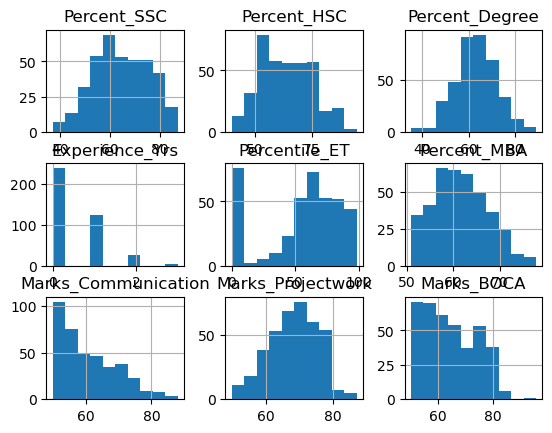

In [87]:
plt.figure(figsize=(10,8))
df_num.hist()

In [88]:
# since many of the num independent variables having skewness we can try applying transformation technique on them 
# and build model on transformed data

In [89]:
df_num['log_percent_ssc']= np.log(df_num['Percent_SSC'])
df_num['log_percent_hsc']= np.log(df_num['Percent_HSC'])
df_num['log_percent_degree']= np.log(df_num['Percent_Degree'])
#df_num['log_Experience_Yrs']= np.log(df_num['Experience_Yrs'])
df_num['log_Percentile_ET']= np.log(df_num['Percentile_ET'])
df_num['log_percent_mba']= np.log(df_num['Percent_MBA'])
df_num['log_marks_boca']= np.log(df_num['Marks_BOCA'])
df_num['log_marks_comm']= np.log(df_num['Marks_Communication'])
df_num['log_marks_pw']= np.log(df_num['Marks_Projectwork'])

In [228]:
df_num['log_Experience_Yrs']

0     -inf
1      0.0
2     -inf
3     -inf
4      0.0
      ... 
386   -inf
387   -inf
388   -inf
389   -inf
390   -inf
Name: log_Experience_Yrs, Length: 391, dtype: float64